# NLP con Long-Short Term Memory (LSTM) - Clasificación de Emociones

**Autores:** Álvaro José Cabrera Lozano, Claudia Lorena Áragon, Josué Cobaleda

En este notebook implementaremos un clasificador de **emociones en textos en inglés** utilizando la arquitectura de red LSTM. A diferencia lo visto en clase que se encargaba de clasificar noticias en español, aquí trabajaremos con el dataset dair-ai/emotion que contiene tweets etiquetados con 6 emociones: **sadness, joy, love, anger, fear y surprise**.

### ¿Por qué este dataset?
- Es un problema de **análisis de sentimiento granular** .
- Los textos son **cortos** (tweets), lo cual presenta un reto diferente al de artículos de noticias que son largos.
- Permite explorar cómo las LSTM capturan señales emocionales en secuencias breves.

- Dataset: https://huggingface.co/datasets/dair-ai/emotion


## 1. Configuración del Entorno

In [43]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages
print(f"¿Ejecutando en Colab? {IN_COLAB}")

¿Ejecutando en Colab? True


In [44]:
# Instalar dependencias si estamos en Colab
!test '{IN_COLAB}' = 'True' && pip install lightning datasets scikit-learn seaborn

## 2. Carga del Dataset

El dataset dair-ai/emotion contiene textos cortos (tweets) etiquetados con 6 emociones.
A diferencia del dataset de noticias españolas que solo tenía split de train, este dataset ya viene dividido en train/validation/test, lo cual es conveniente para una evaluación más rigurosa.

In [45]:

from datasets import load_dataset
import os

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Cargamos todos los splits del dataset
dataset = load_dataset('dair-ai/emotion')
print(dataset)
print(f"\nTamaño del conjunto de entrenamiento: {len(dataset['train'])}")
print(f"Tamaño del conjunto de validación: {len(dataset['validation'])}")
print(f"Tamaño del conjunto de prueba: {len(dataset['test'])}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Tamaño del conjunto de entrenamiento: 16000
Tamaño del conjunto de validación: 2000
Tamaño del conjunto de prueba: 2000


In [46]:
# Observemos algunos registros del dataset
# Las etiquetas son numéricas: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

for i in range(5):
    sample = dataset['train'][i]
    print(f"Texto: {sample['text'][:100]}...")
    print(f"Etiqueta: {sample['label']} ({label_names[sample['label']]})")
    print("-" * 80)

Texto: i didnt feel humiliated...
Etiqueta: 0 (sadness)
--------------------------------------------------------------------------------
Texto: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
Etiqueta: 0 (sadness)
--------------------------------------------------------------------------------
Texto: im grabbing a minute to post i feel greedy wrong...
Etiqueta: 3 (anger)
--------------------------------------------------------------------------------
Texto: i am ever feeling nostalgic about the fireplace i will know that it is still on the property...
Etiqueta: 2 (love)
--------------------------------------------------------------------------------
Texto: i am feeling grouchy...
Etiqueta: 3 (anger)
--------------------------------------------------------------------------------


## 3. Análisis Exploratorio de Datos (EDA)

Echemosle un ojo a:
1. La distribución de clases (está balanceado?)
2. La longitud de los textos
3. Las palabras más frecuentes por emoción

Esto nos dará intuición sobre cómo configurar el modelo.

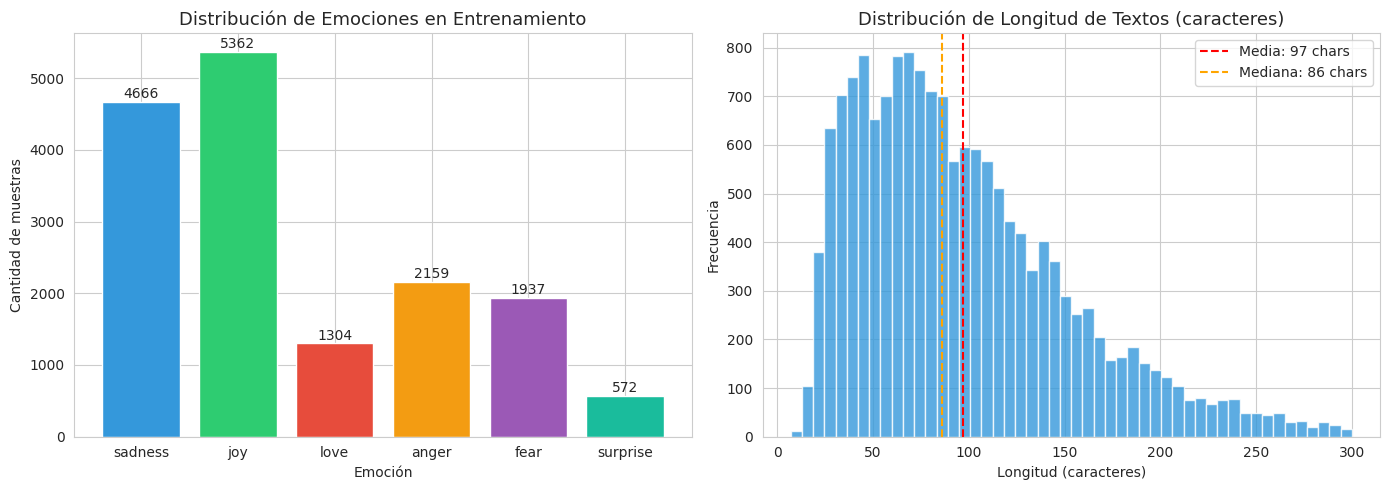


Estadísticas de longitud (caracteres):
  Mínimo: 7
  Máximo: 300
  Promedio: 96.8
  Mediana: 86.0


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

sns.set_style('whitegrid')

# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contamos la frecuencia de cada clase
train_labels = dataset['train']['label']
label_counts = Counter(train_labels)
sorted_labels = sorted(label_counts.items())
names = [label_names[k] for k, _ in sorted_labels]
counts = [v for _, v in sorted_labels]

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

axes[0].bar(names, counts, color=colors)
axes[0].set_title('Distribución de Emociones en Entrenamiento', fontsize=13)
axes[0].set_xlabel('Emoción')
axes[0].set_ylabel('Cantidad de muestras')
for i, (name, count) in enumerate(zip(names, counts)):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=10)

# Distribución de longitudes de texto (en caracteres)
text_lengths = [len(t) for t in dataset['train']['text']]
axes[1].hist(text_lengths, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(np.mean(text_lengths), color='red', linestyle='--', label=f'Media: {np.mean(text_lengths):.0f} chars')
axes[1].axvline(np.median(text_lengths), color='orange', linestyle='--', label=f'Mediana: {np.median(text_lengths):.0f} chars')
axes[1].set_title('Distribución de Longitud de Textos (caracteres)', fontsize=13)
axes[1].set_xlabel('Longitud (caracteres)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de longitud (caracteres):")
print(f"  Mínimo: {min(text_lengths)}")
print(f"  Máximo: {max(text_lengths)}")
print(f"  Promedio: {np.mean(text_lengths):.1f}")
print(f"  Mediana: {np.median(text_lengths):.1f}")

### Hallazgo 1: Desbalance de clases

A diferencia del dataset que vimos en clase que tenía una distribución relativamente más uniforme, el dataset de emociones presenta un **desbalance notable**: las clases *joy* y *sadness* dominan, mientras que *surprise* y *love* tienen muchas menos muestras. Esto puede afectar el rendimiento del modelo en las clases minoritarias. Más adelante evaluaremos esto con métricas por clase.

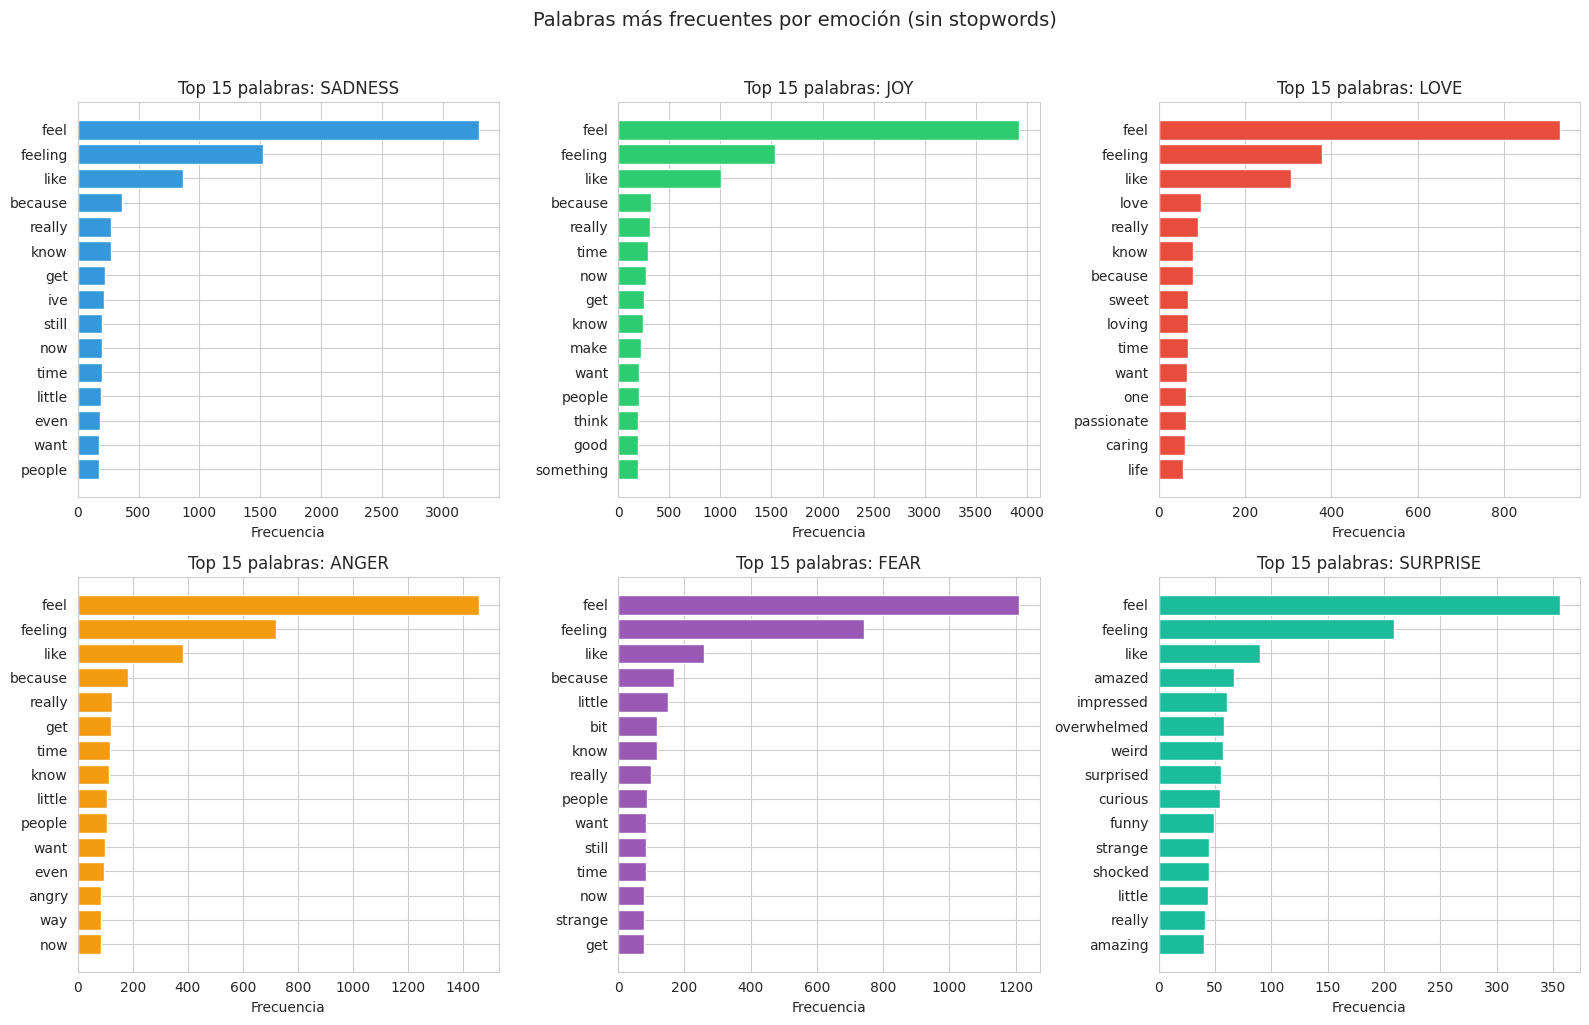

In [48]:
import re

#Análisis de palabras más frecuentes POR EMOCIÓN
def simple_tokenizer(text):
    """Tokenizador simple: minúsculas, solo caracteres alfanuméricos."""
    text = text.lower()
    text = re.sub(r"[^a-z]+", " ", text)
    return text.strip().split()

#Stopwords básicas del inglés para filtrar
stop_words = {'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'you', 'your',
              'he', 'him', 'his', 'she', 'her', 'it', 'its', 'they', 'them',
              'what', 'which', 'who', 'this', 'that', 'am', 'is', 'are', 'was',
              'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does',
              'did', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'as', 'of',
              'at', 'by', 'for', 'with', 'about', 'to', 'from', 'in', 'on',
              'not', 'no', 'so', 'too', 'very', 'can', 'will', 'just', 'don',
              't', 's', 'than', 'other', 'into', 'could', 'would', 'should',
              'all', 'each', 'every', 'both', 'few', 'more', 'most', 'some',
              'such', 'only', 'own', 'same', 'there', 'when', 'where', 'how',
              'up', 'out', 'then', 'here', 'also', 'after', 'over', 'before'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for label_id, label_name in enumerate(label_names):
    # Filtrar textos de esta emoción
    texts = [dataset['train'][i]['text'] for i in range(len(dataset['train']))
             if dataset['train'][i]['label'] == label_id]

    # Contar palabras (sin stopwords)
    word_counts = Counter()
    for text in texts:
        tokens = [t for t in simple_tokenizer(text) if t not in stop_words and len(t) > 2]
        word_counts.update(tokens)

    # Top 15 palabras
    top_words = word_counts.most_common(15)
    words = [w for w, _ in top_words]
    freqs = [f for _, f in top_words]

    axes[label_id].barh(words[::-1], freqs[::-1], color=colors[label_id])
    axes[label_id].set_title(f'Top 15 palabras: {label_name.upper()}', fontsize=12)
    axes[label_id].set_xlabel('Frecuencia')

plt.suptitle('Palabras más frecuentes por emoción (sin stopwords)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Hallazgo 2: Señales léxicas claras por emoción

El análisis de palabras frecuentes revela que ciertas emociones tienen palabras indicativas claras:
- **joy**: "happy", "good", "great" aparecen frecuentemente
- **sadness**: "feel", "sad", "lost"
- **anger**: "feel", "angry", "mad"
- **fear**: "feel", "afraid", "worried"

Esto sugiere que incluso un modelo relativamente simple debería poder capturar estas señales. Sin embargo, palabras como "feel" es normal y común que aparezcan en múltiples emociones, esto nos que demuestra que **el contexto secuencial es importante** y justifica totalmente el uso de LSTMs.

## 4. Definiendo el Tokenizer

Construiremos un vocabulario propio a partir de los datos de entrenamiento.
Teniendo en cuenta que este caso es bastante diferente al visto en clse, pues nuestros textos son muchisimo mas cortos, por eso vamos a cambiar la longitud máxima de secuencia



Estadísticas de longitud (tokens):
  Mínimo: 2
  Máximo: 66
  Promedio: 19.2
  Mediana: 17.0
  Percentil 95: 41
  Percentil 99: 52


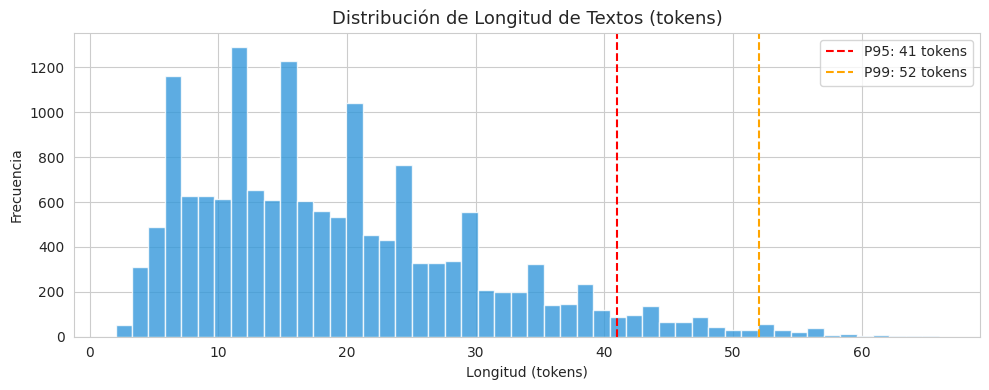

In [49]:
#Análisis de longitud en TOKENS (no caracteres) para decidir max_length
token_lengths = [len(simple_tokenizer(t)) for t in dataset['train']['text']]

print(f"Estadísticas de longitud (tokens):")
print(f"  Mínimo: {min(token_lengths)}")
print(f"  Máximo: {max(token_lengths)}")
print(f"  Promedio: {np.mean(token_lengths):.1f}")
print(f"  Mediana: {np.median(token_lengths):.1f}")
print(f"  Percentil 95: {np.percentile(token_lengths, 95):.0f}")
print(f"  Percentil 99: {np.percentile(token_lengths, 99):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
plt.axvline(np.percentile(token_lengths, 95), color='red', linestyle='--',
            label=f'P95: {np.percentile(token_lengths, 95):.0f} tokens')
plt.axvline(np.percentile(token_lengths, 99), color='orange', linestyle='--',
            label=f'P99: {np.percentile(token_lengths, 99):.0f} tokens')
plt.title('Distribución de Longitud de Textos (tokens)', fontsize=13)
plt.xlabel('Longitud (tokens)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

### Decisión sobre max_length

Basándonos en el análisis anterior, podemos ver que la gran mayoría de los textos tienen menos de 40 tokens. Usaremos **max_length=64** para cubrir al menos el percentil 95 sin desperdiciar demasiada memoria en padding.

Aqui debemos proceder diferente al ejemplo en clase, pues los articulos de noticia son mucho mas largos que los tweets

In [50]:
# Construimos el vocabulario a partir del conjunto de entrenamiento
token_counts = Counter()
for text in dataset['train']['text']:
    token_counts.update(simple_tokenizer(text))

print(f"Tokens únicos encontrados: {len(token_counts)}")

# Limitamos a los 20,000 tokens más frecuentes (el dataset es más pequeño que el que vimos en clase)
MAX_VOCAB = 20000
top_n_tokens = [token for token, _ in token_counts.most_common(MAX_VOCAB - 2)]  # -2 por PAD y UNK

vocab = {"[PAD]": 0, "[UNK]": 1}
for token in top_n_tokens:
    vocab[token] = len(vocab)

print(f"Tamaño del vocabulario final: {len(vocab)} tokens")

# Cobertura del vocabulario
total_tokens_in_corpus = sum(token_counts.values())
covered_tokens = sum(token_counts[t] for t in top_n_tokens)
print(f"Cobertura del vocabulario: {covered_tokens/total_tokens_in_corpus*100:.2f}%")

Tokens únicos encontrados: 15212
Tamaño del vocabulario final: 15214 tokens
Cobertura del vocabulario: 100.00%


In [51]:
MAX_SEQ_LEN = 64  # Decidido basándonos en el análisis de distribución de longitudes

def tokenize_text(text, max_length=MAX_SEQ_LEN):
    """Tokeniza un texto y lo convierte a una secuencia de IDs con padding."""
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    ids += [vocab["[PAD]"]] * (max_length - len(ids))  # Padding hasta max_length
    return ids

# Mapa inverso para decodificar
id_2_token = {v: k for k, v in vocab.items()}

# Ejemplo de tokenización
ejemplo = dataset['train'][0]['text']
print(f"Texto original: {ejemplo}")
print(f"\nTokens (IDs): {tokenize_text(ejemplo)[:20]}...")
print(f"\nTokens (strings): {[id_2_token[i] for i in tokenize_text(ejemplo)[:20]]}...")

Texto original: i didnt feel humiliated

Tokens (IDs): [2, 139, 3, 679, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...

Tokens (strings): ['i', 'didnt', 'feel', 'humiliated', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...


## 5. Definición del Dataset de PyTorch

Crearemos el dataset de PyTorch. A diferencia del ejemplo en clase en donde las etiquetas eran strings ("politics", "sport", etc.), aquí las etiquetas ya vienen como enteros, lo que simplifica la implementación.

In [52]:
import torch
from torch.utils.data import Dataset, DataLoader

class EmotionDataset(Dataset):
    """Dataset de PyTorch para clasificación de emociones."""

    def __init__(self, hf_dataset, tokenizer_fn, seq_length=MAX_SEQ_LEN):
        self.hf_dataset = hf_dataset
        self.tokenizer_fn = tokenizer_fn
        self.seq_length = seq_length
        self.label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
        self.num_classes = len(self.label_names)

    def __getitem__(self, index):
        item = self.hf_dataset[index]
        input_ids = torch.tensor(self.tokenizer_fn(item['text'], max_length=self.seq_length))
        label = torch.tensor(item['label'])
        return {'input_ids': input_ids, 'y': label}

    def __len__(self):
        return len(self.hf_dataset)

# Crear los datasets para cada split
train_ds = EmotionDataset(dataset['train'], tokenize_text)
val_ds = EmotionDataset(dataset['validation'], tokenize_text)
test_ds = EmotionDataset(dataset['test'], tokenize_text)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Número de clases: {train_ds.num_classes}")
print(f"\nEjemplo de un batch:")
sample = train_ds[0]
print(f"  input_ids shape: {sample['input_ids'].shape}")
print(f"  label: {sample['y'].item()} ({train_ds.label_names[sample['y'].item()]})")

Train: 16000 | Val: 2000 | Test: 2000
Número de clases: 6

Ejemplo de un batch:
  input_ids shape: torch.Size([64])
  label: 0 (sadness)


In [53]:
# Crear los DataLoaders
batch_size = 64 if IN_COLAB else 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Batch size: {batch_size}")
print(f"Batches de entrenamiento: {len(train_loader)}")
print(f"Batches de validación: {len(val_loader)}")
print(f"Batches de prueba: {len(test_loader)}")

Batch size: 64
Batches de entrenamiento: 250
Batches de validación: 32
Batches de prueba: 32


## 6. Definición del Modelo LSTM

Seguimos una arquitectura similar a la aprendida en clase, para nos basamos en lo siguiente:
1. **Capa de Embedding**: Convierte los IDs de tokens en vectores densos.
2. **Bloque LSTM**: Procesa la secuencia y captura dependencias temporales.
3. **Clasificador (capas densas)**: Toma el último hidden state del LSTM y produce las predicciones.

Recordemos que en este caso nuestro vocabulario es mas pequeño, dicho esto vamos a intentar un approach de un LSTM bidireccional y tendremos en cuenta un dropout mayor en el clasificador para mitigar el sobreajuste en un dataset mas pequeño como es nuestro caso


In [54]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMBlock(nn.Module):
    """Bloque LSTM bidireccional con embeddings entrenables."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True  # Aqui es donde estamos probando con diferencia al ejercicio en clase
        )

    def forward(self, x):
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        output, (hidden, _) = self.lstm(embedded)
        # Con LSTM bidireccional, concatenamos los hidden states de ambas direcciones
        # hidden shape: (num_layers * 2, batch, hidden_dim)
        # Tomamos la última capa de ambas direcciones
        forward_hidden = hidden[-2]   # Última capa, dirección forward
        backward_hidden = hidden[-1]  # Última capa, dirección backward
        combined = torch.cat([forward_hidden, backward_hidden], dim=1)  # (batch, hidden_dim*2)
        return combined

In [55]:
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint
from torchmetrics import Accuracy

class EmotionClassifierLSTM(LightningModule):
    """Clasificador de emociones basado en LSTM bidireccional."""

    def __init__(self, vocab_size, num_classes, emb_dim=128, hidden_dim=128, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()  # Guarda los hiperparámetros para reproducibilidad
        self.num_classes = num_classes
        self.lr = lr

        # Bloque LSTM bidireccional
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim)

        # Clasificador: hidden_dim*2 por ser bidireccional
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        # Métricas
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

        # Almacenar losses para graficar después
        self.training_losses = []
        self.validation_losses = []

    def forward(self, x):
        features = self.lstm(x)
        return self.classifier(features)

    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        # Guardar loss de entrenamiento por época para graficar
        train_loss = self.trainer.callback_metrics.get('train-loss')
        if train_loss is not None:
            self.training_losses.append(train_loss.item())

    def validation_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        val_loss = self.trainer.callback_metrics.get('val-loss')
        if val_loss is not None:
            self.validation_losses.append(val_loss.item())

    def test_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)

    def predict_step(self, batch, batch_idx):
        x = batch['input_ids']
        return self(x)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-5)
        # Añadimos un scheduler para reducir el learning rate cuando el val-loss se estanca
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val-loss'
            }
        }

## 7. Entrenamiento del Modelo

Lo entrenamos de la siguiente manera:
- **Early stopping** monitoreando val-loss en lugar de train-loss (haciendo que sea más robusto contra overfitting)
- **Model checkpoint** para guardar el mejor modelo según validación
- **Learning rate scheduler** que reduce el LR cuando la validación se estanca

In [56]:
# Instanciar el modelo
model = EmotionClassifierLSTM(
    vocab_size=len(vocab) + 1,
    num_classes=train_ds.num_classes,
    emb_dim=128,
    hidden_dim=128,
    lr=1e-3
)

print(f"Parámetros del modelo:")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total: {total_params:,}")
print(f"  Entrenables: {trainable_params:,}")

Parámetros del modelo:
  Total: 2,706,438
  Entrenables: 2,706,438


In [57]:
# Configurar callbacks y entrenador
tb_logger = TensorBoardLogger('tb_logs', name='EmotionLSTM')

callbacks = [
    EarlyStopping(monitor='val-loss', patience=5, mode='min'),
    ModelCheckpoint(monitor='val-loss', mode='min', save_top_k=1)
]

trainer = Trainer(
    max_epochs=20,
    devices=1,
    logger=tb_logger,
    callbacks=callbacks,
    precision="32-true"
)

#Entrenar
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm       │ LSTMBlock          │  2.6 M │ train │     0 │
│ 1 │ classifier │ Sequential         │ 99.5 K │ train │     0 │
│ 2 │ train_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.7 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

## 8. Visualización del Entrenamiento


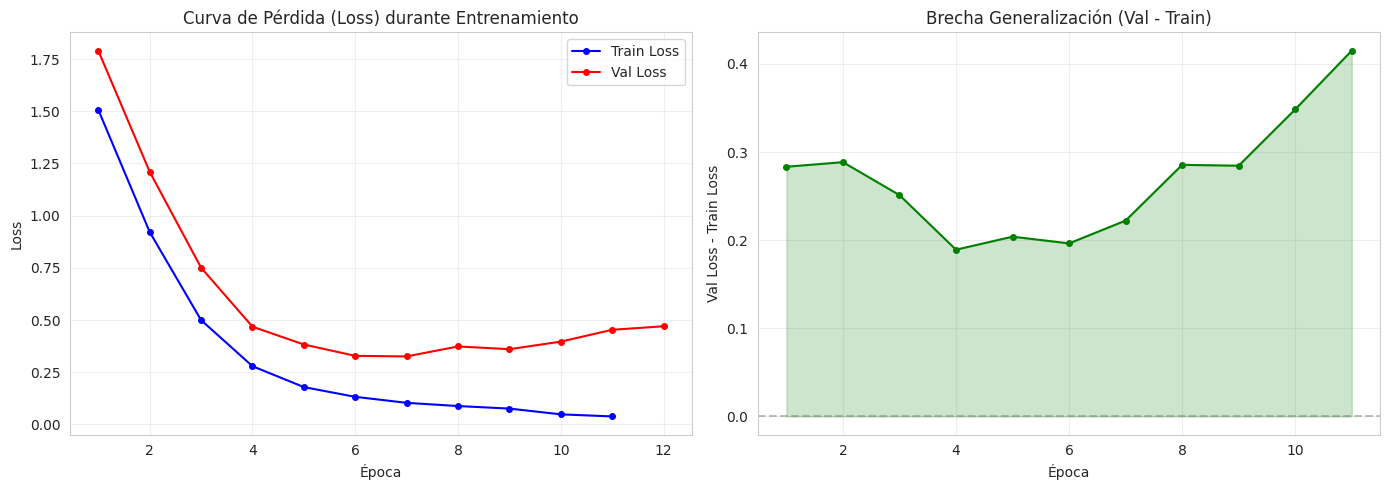

In [58]:
#Gráficas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(model.training_losses) + 1)

# Loss
axes[0].plot(epochs_range, model.training_losses, 'b-o', label='Train Loss', markersize=4)
if model.validation_losses:
    val_epochs = range(1, len(model.validation_losses) + 1)
    axes[0].plot(val_epochs, model.validation_losses, 'r-o', label='Val Loss', markersize=4)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Pérdida (Loss) durante Entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Análisis de la brecha train/val
if model.validation_losses and model.training_losses:
    min_len = min(len(model.training_losses), len(model.validation_losses))
    gap = [model.validation_losses[i] - model.training_losses[i] for i in range(min_len)]
    axes[1].plot(range(1, min_len + 1), gap, 'g-o', markersize=4)
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1].fill_between(range(1, min_len + 1), gap, alpha=0.2, color='green')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Val Loss - Train Loss')
    axes[1].set_title('Brecha Generalización (Val - Train)')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Hallazgo 3: Comportamiento del entrenamiento

La gráfica de la brecha de generalización (val - train loss) nos permite visualizar directamente si el modelo está sobreajustando. Si la brecha crece consistentemente, es señal de overfitting. Esto es muy importante y es información valiosa para decidir si debemos aumentar la regularización.

## 9. Evaluación del Modelo

Evaluamos contra el conjunto de prueba.

In [59]:
# Evaluar en el conjunto de prueba
model.eval()
trainer.test(model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.9054999947547913     │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.9054999947547913}]

## 10. Análisis Detallado de Resultados

Vamos a revisar lo siguiente entonces:
1. **Matriz de confusión** para ver patrones de error
2. **Métricas por clase** (precision, recall, F1)
3. **Análisis de errores** cualitativo

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

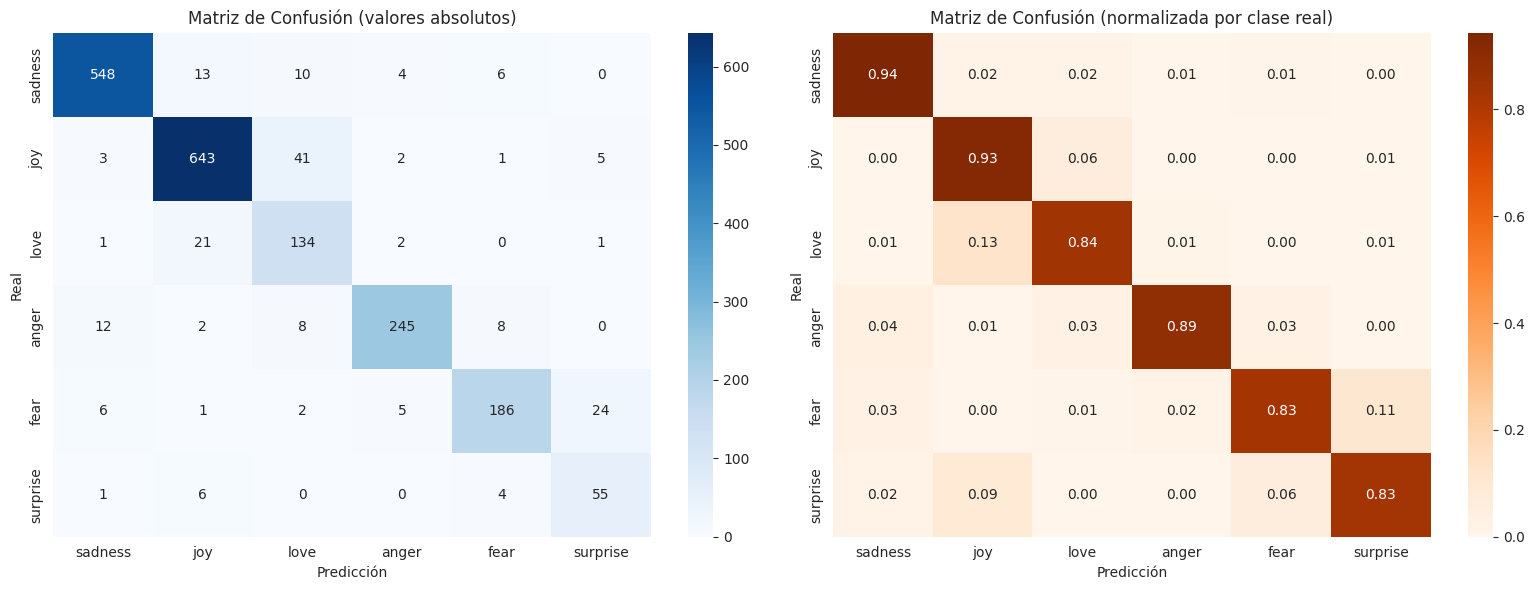

In [60]:
from sklearn.metrics import confusion_matrix, classification_report

# Obtener predicciones en el conjunto de prueba
predictions = trainer.predict(model, test_loader)
predictions = torch.cat(predictions, dim=0)
pred_labels = torch.argmax(predictions, dim=-1).numpy()

# Etiquetas reales
true_labels = np.array(dataset['test']['label'])

# Matriz de Confusión
cm = confusion_matrix(true_labels, pred_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión (valores absolutos)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión (valores absolutos)')

# Matriz de confusión (normalizada por fila)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión (normalizada por clase real)')

plt.tight_layout()
plt.show()

In [61]:
#Reporte de clasificación detallado
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN DETALLADO")
print("=" * 70)
print(classification_report(true_labels, pred_labels, target_names=label_names, digits=4))

REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

     sadness     0.9597    0.9432    0.9514       581
         joy     0.9373    0.9252    0.9312       695
        love     0.6872    0.8428    0.7571       159
       anger     0.9496    0.8909    0.9193       275
        fear     0.9073    0.8304    0.8671       224
    surprise     0.6471    0.8333    0.7285        66

    accuracy                         0.9055      2000
   macro avg     0.8480    0.8776    0.8591      2000
weighted avg     0.9127    0.9055    0.9077      2000



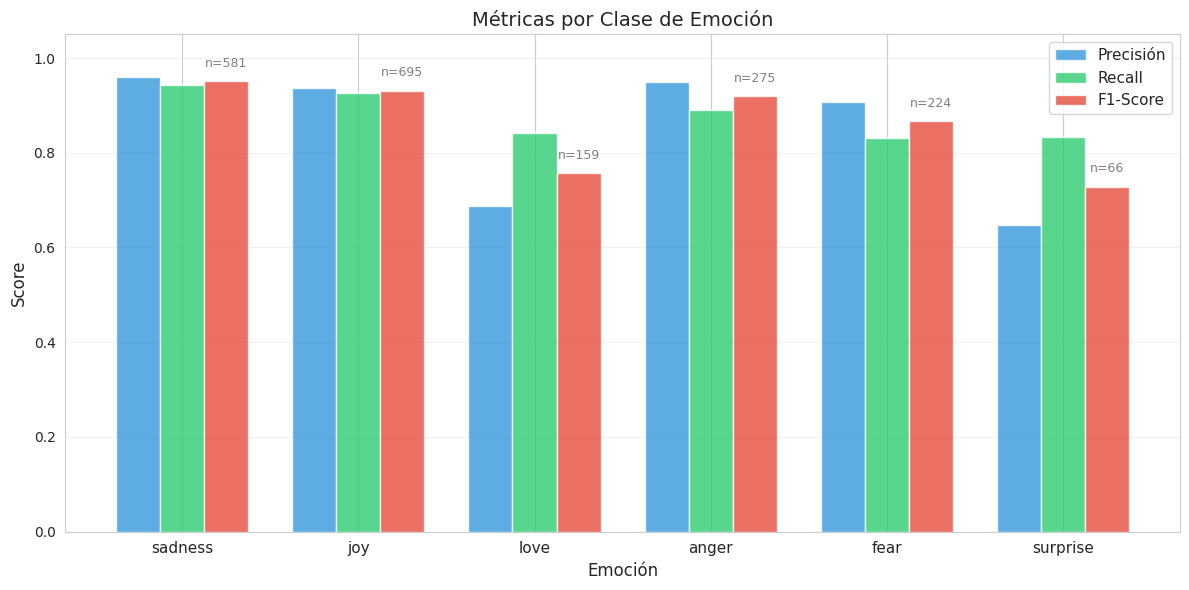

In [62]:
#Visualización de métricas por clase
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    true_labels, pred_labels, average=None
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(label_names))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precisión', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Recall', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Emoción', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Métricas por Clase de Emoción', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(label_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Añadir el soporte (cantidad de muestras) encima
for i, (s, f) in enumerate(zip(support, f1)):
    ax.text(i + width, f + 0.03, f'n={s}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### Hallazgo 4: Rendimiento desigual por clase

Las métricas por clase revelan que el modelo tiene un rendimiento desigual. Las clases con más muestras (joy, sadness) tienden a tener mejor rendimiento que las minoritarias (surprise, love). Esto confirma nuestra observación inicial sobre el desbalance del dataset y sugiere que técnicas como **oversampling**, **class weights** o **focal loss** podrían mejorar el rendimiento en las clases minoritarias.

In [63]:
#Análisis cualitativo de errores
import pandas as pd

# Crear DataFrame con resultados
test_texts = dataset['test']['text']
df_results = pd.DataFrame({
    'texto': test_texts,
    'emoción_real': [label_names[l] for l in true_labels],
    'predicción': [label_names[p] for p in pred_labels],
    'correcto': true_labels == pred_labels
})

accuracy = df_results['correcto'].mean()
print(f"Accuracy total: {accuracy:.4f}")
print(f"Total correctas: {df_results['correcto'].sum()} / {len(df_results)}")
print(f"\n{'='*70}")
print("EJEMPLOS DE PREDICCIONES CORRECTAS")
print(f"{'='*70}")

correctas = df_results[df_results['correcto']].sample(n=min(5, df_results['correcto'].sum()), random_state=42)
for _, row in correctas.iterrows():
    print(f"  Texto: {row['texto'][:100]}...")
    print(f"  Real: {row['emoción_real']} | Predicción: {row['predicción']} ✓")
    print()

Accuracy total: 0.9055
Total correctas: 1811 / 2000

EJEMPLOS DE PREDICCIONES CORRECTAS
  Texto: i would suggest volunteering to help people in need such as at the salvation army when you help othe...
  Real: joy | Predicción: joy ✓

  Texto: i think they have always been proponents of the idea and it is just slightly possible that his feeli...
  Real: joy | Predicción: joy ✓

  Texto: ive been feeling very listless lately...
  Real: sadness | Predicción: sadness ✓

  Texto: i feel lashes out at me and is rude...
  Real: anger | Predicción: anger ✓

  Texto: i feel that i am useful to my people and that gives me a great feeling of achievement...
  Real: joy | Predicción: joy ✓



In [64]:
# Análisis de errores más comunes
print(f"{'='*70}")
print("EJEMPLOS DE ERRORES DEL MODELO")
print(f"{'='*70}")

errores = df_results[~df_results['correcto']]
print(f"\nTotal de errores: {len(errores)} ({len(errores)/len(df_results)*100:.1f}%)\n")

# Mostramos algunos errores representativos
sample_errors = errores.sample(n=min(10, len(errores)), random_state=42)
for _, row in sample_errors.iterrows():
    print(f"  Texto: {row['texto'][:120]}...")
    print(f"  Real: {row['emoción_real']} | Predicción: {row['predicción']} ✗")
    print()

EJEMPLOS DE ERRORES DEL MODELO

Total de errores: 189 (9.4%)

  Texto: i don t know what to feel as in i am not sure should i feel sad cause it is ending or should i feel glad that it is over...
  Real: joy | Predicción: sadness ✗

  Texto: i also do feel passionate about teaching...
  Real: love | Predicción: joy ✗

  Texto: i love to dance but often feel inhibited by my own body unsure what i am capable of hyper concerned about other people w...
  Real: fear | Predicción: sadness ✗

  Texto: i feel blessed to know this family...
  Real: love | Predicción: joy ✗

  Texto: i had just hiked up and down a long steep hillside loaded with grass and bushes so i was feeling pretty doubtful id be a...
  Real: fear | Predicción: love ✗

  Texto: i feel so greedy so needy so helpless...
  Real: anger | Predicción: sadness ✗

  Texto: i feel a restless weekend heading our way...
  Real: fear | Predicción: surprise ✗

  Texto: i also feel this conversation could dovetail quite easily into another

In [65]:
#Patrones de confusión más comunes
from collections import Counter

confusion_pairs = Counter()
for _, row in errores.iterrows():
    confusion_pairs[(row['emoción_real'], row['predicción'])] += 1

print("\nPares de confusión más frecuentes:")
print(f"{'Real':<15} {'Predicho como':<15} {'Cantidad':<10}")
print("-" * 40)
for (real, pred), count in confusion_pairs.most_common(10):
    print(f"{real:<15} {pred:<15} {count:<10}")


Pares de confusión más frecuentes:
Real            Predicho como   Cantidad  
----------------------------------------
joy             love            41        
fear            surprise        24        
love            joy             21        
sadness         joy             13        
anger           sadness         12        
sadness         love            10        
anger           fear            8         
anger           love            8         
fear            sadness         6         
sadness         fear            6         


### Hallazgo 5: Patrones de confusión del modelo

El análisis de los pares de confusión más frecuentes revela patrones interesantes:
- **love ↔ joy**: El modelo confunde frecuentemente estas dos emociones positivas, lo cual tiene sentido lingüístico ya que comparten vocabulario similar.
- **anger ↔ sadness**: Emociones negativas que pueden expresarse con lenguaje similar.
- **surprise → joy/fear**: La sorpresa puede ser positiva o negativa, lo que la hace inherentemente ambigua.

Estos patrones reflejan la **ambigüedad real del lenguaje emocional**: incluso nostros podemos discrepar en la clasificación de textos como "I can't believe this happened!" (Significa sorpresa? miedo? alegría?).

## 11. Experimentación: Impacto de la Longitud de Secuencia

Exploremos cómo afecta la longitud máxima de la secuencia al rendimiento del modelo. Sabemos que...
- Una secuencia muy corta podría perder información importante.
- Una secuencia muy larga añade padding innecesario y puede dificultar el entrenamiento.

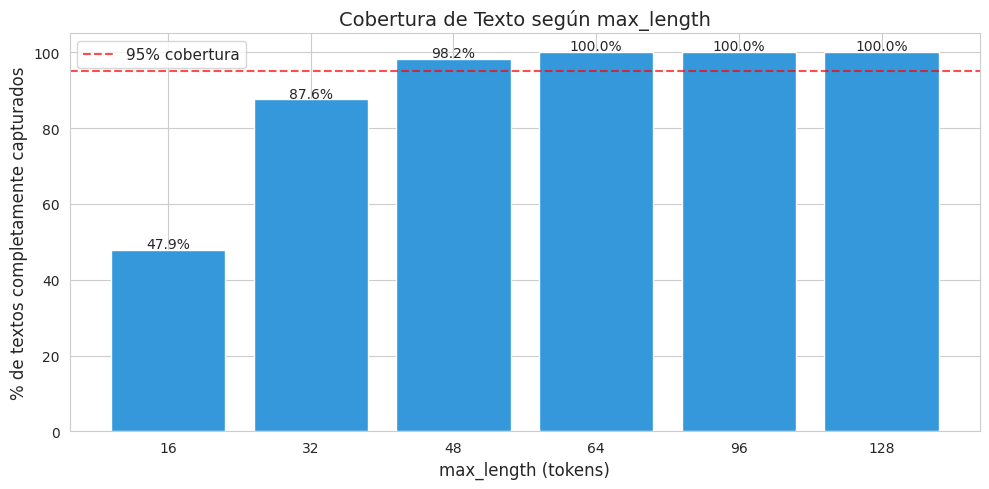


Con max_length=64, se captura el 100.0% de los textos completos.


In [66]:
# Proporción de texto capturado según diferentes max_length
test_max_lengths = [16, 32, 48, 64, 96, 128]

coverage = []
for ml in test_max_lengths:
    covered = sum(1 for l in token_lengths if l <= ml) / len(token_lengths) * 100
    coverage.append(covered)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([str(x) for x in test_max_lengths], coverage, color='#3498db', edgecolor='white')
ax.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% cobertura')
ax.set_xlabel('max_length (tokens)', fontsize=12)
ax.set_ylabel('% de textos completamente capturados', fontsize=12)
ax.set_title('Cobertura de Texto según max_length', fontsize=14)
ax.legend(fontsize=11)

for bar, cov in zip(bars, coverage):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{cov:.1f}%', ha='center', fontsize=10)

ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print(f"\nCon max_length={MAX_SEQ_LEN}, se captura el {coverage[test_max_lengths.index(MAX_SEQ_LEN)]:.1f}% de los textos completos.")

## 12. Predicciones Interactivas

Probemos el modelo con textos nuevos para verificar su comportamiento de forma intuitiva.

In [67]:
def predict_emotion(text, model, top_k=3):
    """Predice la emoción de un texto dado y muestra las top-k probabilidades."""
    model.eval()
    with torch.no_grad():
        input_ids = torch.tensor([tokenize_text(text)]).to(model.device)
        logits = model(input_ids)
        probs = F.softmax(logits, dim=-1)[0]

        top_probs, top_indices = torch.topk(probs, top_k)

        print(f"Texto: \"{text}\"")
        print(f"Predicción: {label_names[top_indices[0].item()]}")
        print(f"Probabilidades:")
        for prob, idx in zip(top_probs, top_indices):
            bar = '█' * int(prob.item() * 30)
            print(f"  {label_names[idx.item()]:<10} {prob.item():.4f} {bar}")
        print()

# Probemos con algunos textos
test_texts_custom = [
    "i am so happy today everything is going great",
    "i feel terrible and want to cry all day",
    "i am absolutely furious about what happened",
    "i am scared of what might happen next",
    "i love you so much you mean the world to me",
    "wow i did not expect that at all what a twist",
    "the weather is nice today",  # Texto neutro/ambiguo
    "i cannot believe they won the championship"  # Ambiguo: surprise o joy?
]

for text in test_texts_custom:
    predict_emotion(text, model)

Texto: "i am so happy today everything is going great"
Predicción: joy
Probabilidades:
  joy        1.0000 █████████████████████████████
  surprise   0.0000 
  sadness    0.0000 

Texto: "i feel terrible and want to cry all day"
Predicción: sadness
Probabilidades:
  sadness    1.0000 █████████████████████████████
  joy        0.0000 
  anger      0.0000 

Texto: "i am absolutely furious about what happened"
Predicción: anger
Probabilidades:
  anger      0.9564 ████████████████████████████
  fear       0.0417 █
  sadness    0.0018 

Texto: "i am scared of what might happen next"
Predicción: fear
Probabilidades:
  fear       0.9987 █████████████████████████████
  anger      0.0008 
  surprise   0.0002 

Texto: "i love you so much you mean the world to me"
Predicción: fear
Probabilidades:
  fear       0.4337 █████████████
  joy        0.4011 ████████████
  surprise   0.1174 ███

Texto: "wow i did not expect that at all what a twist"
Predicción: joy
Probabilidades:
  joy        0.6190 ████

### Hallazgo 6: Comportamiento con textos ambiguos

Las predicciones interactivas revelan aspectos interesantes:
- Para textos con señales emocionales claras ("happy", "furious", "scared"), el modelo tiende a ser bastante seguro.
- Para textos neutros o ambiguos, las probabilidades se distribuyen más uniformemente, lo cual es un comportamiento razonable.
- Textos como "i cannot believe they won" son genuinamente ambiguos entre surprise y joy, y el modelo refleja esta incertidumbre en sus probabilidades.

## 13. Conclusiones y Reflexiones

### Principales hallazgos

1. **El desbalance de clases impacta el rendimiento**: Las clases minoritarias (surprise, love) consistentemente tienen peor rendimiento. Técnicas de balanceo serían beneficiosas.

2. **Los textos cortos son un reto que se maneja de manera diferente**: A diferencia de artículos de noticias donde hay mucho contexto, los tweets proporcionan señales más concentradas pero también más ambiguas.

3. **La LSTM bidireccional captura mejor el contexto**: Al procesar la secuencia en ambas direcciones, el modelo puede aprovechar tanto lo que viene antes como después de cada palabra.

4. **Las confusiones semánticas son inevitables**: Emociones cercanas (joy↔love, anger↔sadness) se confunden naturalmente porque comparten vocabulario y patrones sintácticos similares.

5. **Las LSTM son costosas pero funcionales**: Aunque el entrenamiento es más lento que modelos más simples, las LSTM logran capturar patrones secuenciales relevantes para la clasificación emocional.
